# Отчёт об обучении MARL

Кривые обучения по каждому learner'у и проверка «обученный против случайного» для CTDE-прогона. Список агентов читается из сохранённой кривой, так что отчёт работает и для одиночного агента, и для совместного прогона.

Сначала: `python -m training.marl.train --agents ...`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "training" / "config.py").exists():
            return candidate
    raise RuntimeError("project root not found (training/config.py)")


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.config import DELIVERY_AGENTS, N_DELIVERY_WINDOWS
from env.training_env import ColdChainTrainingEnv
from training.config import (
    COMPARE_METRIC,
    COMPARE_SEED,
    CURVE_CSV,
    METRIC,
    build_agents,
    env_config,
    module_dir,
)
from training.marl.agents import RandomAgent
from training.marl.evaluate import rollout

curve = pd.read_csv(CURVE_CSV)
AGENTS = [c[len("return_"):] for c in curve.columns if c.startswith("return_")]

plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("trained agents:", AGENTS)

trained agents: ['temperature', 'routing', 'spoilage', 'inventory', 'delivery_0', 'delivery_1', 'delivery_2']


## Кривые обучения

На learner'а: средний жадный return за эпизод (выше = лучше) и его метрика задачи (ниже = лучше) по итерациям обучения.

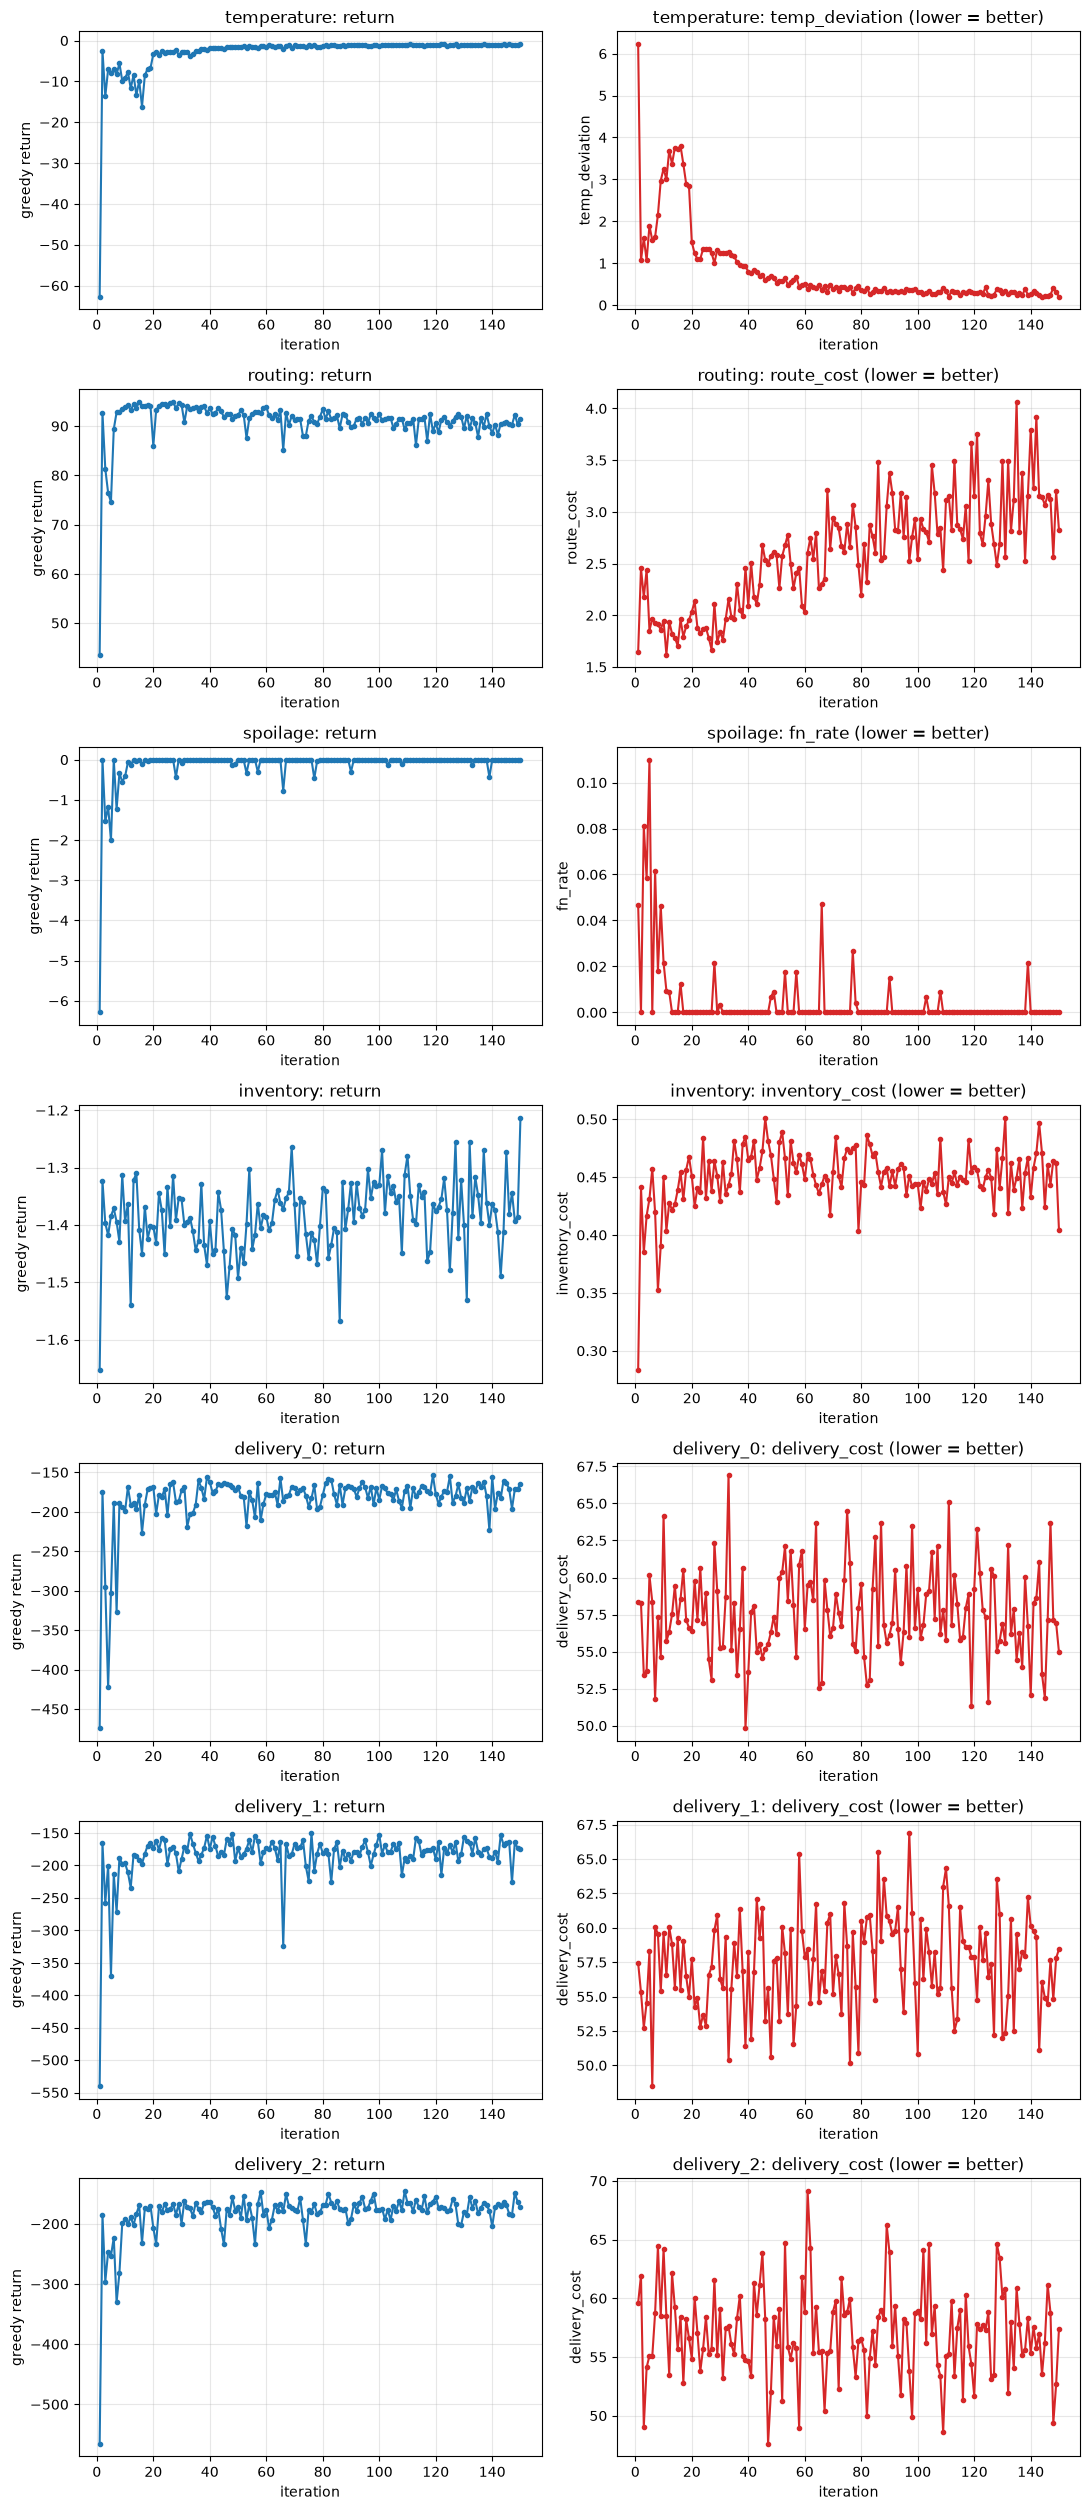

In [2]:
fig, axes = plt.subplots(len(AGENTS), 2, figsize=(11, 3.6 * len(AGENTS)), squeeze=False)
for i, a in enumerate(AGENTS):
    metric_key, direction = METRIC[a]
    goal = "lower = better" if direction == "min" else "higher = better"
    axes[i][0].plot(curve["iteration"], curve[f"return_{a}"], marker="o", ms=3)
    axes[i][0].set(title=f"{a}: return", xlabel="iteration", ylabel="greedy return")
    axes[i][1].plot(curve["iteration"], curve[f"{metric_key}_{a}"], marker="o", ms=3,
                    color="tab:red")
    axes[i][1].set(title=f"{a}: {metric_key} ({goal})", xlabel="iteration",
                   ylabel=metric_key)
fig.tight_layout()
plt.show()

## Обученный против случайного

Жадная обученная политика против случайной на отложенном наборе сидов, каждая — на фиксированном замороженном no-op фоне (активен только проверяемый блок). Методика и метрики (`COMPARE_METRIC`) те же, что в `training.marl.train._compare`: routing сравнивается по return, delivery — по slot_cost; машины доставки — один блок (общая MADDPG-группа).

temperature: trained temp_deviation=0.200  random=12.280  (+98%)
routing: trained return=95.068  random=-8.500  (+1218%)


spoilage: trained fn_rate=0.069  random=0.235  (+71%)


inventory: trained inventory_cost=0.194  random=0.513  (+62%)


delivery: trained slot_cost=4.000  random=2.610  (-53%)


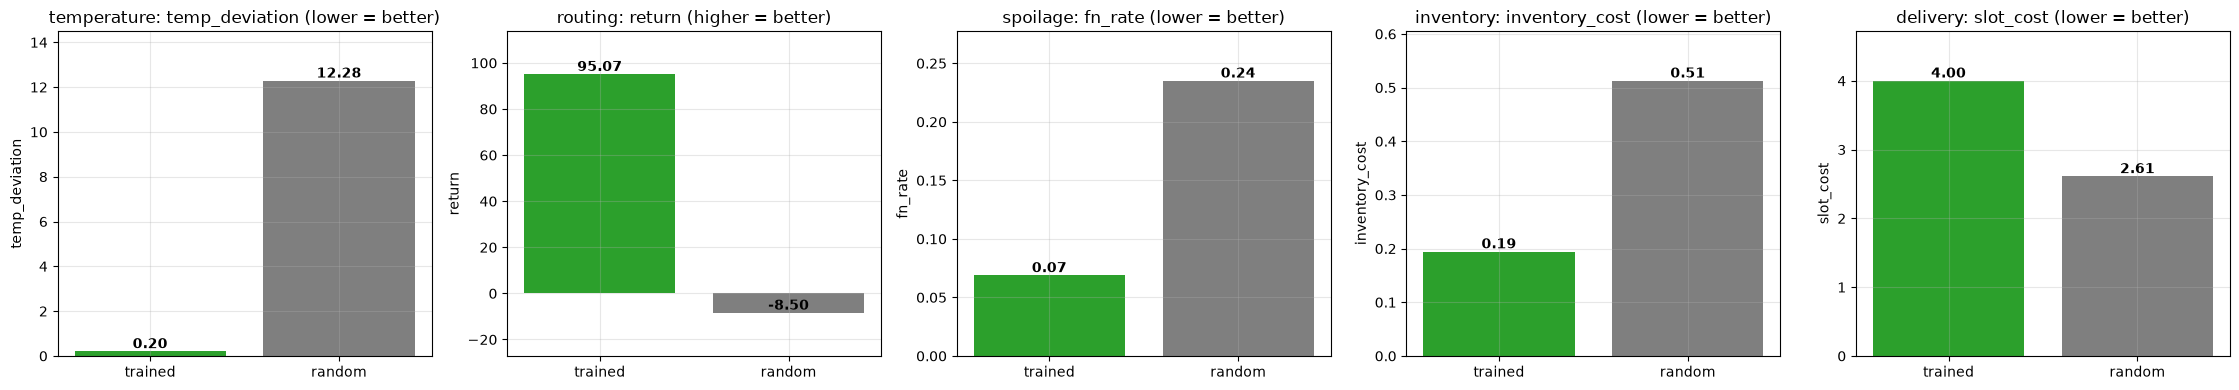

In [3]:
N_EPISODES = 40

blocks = [(a, [a]) for a in AGENTS if a not in DELIVERY_AGENTS]
delivery = [a for a in AGENTS if a in DELIVERY_AGENTS]
if delivery:
    blocks.append(("delivery", delivery))


def block_metric(block, metric_key, random_policy):
    env = ColdChainTrainingEnv(env_config(COMPARE_SEED, block))
    agents = build_agents(env, block)
    if random_policy:
        for a in block:
            agents[a] = RandomAgent(env.action_space(a))
    else:
        agents[block[0]].load(module_dir(block[0]))
    vals = [rollout(env, agents, a, N_EPISODES, metric_key)[1] for a in block]
    return float(np.mean(vals))


fig, axes = plt.subplots(1, len(blocks), figsize=(4.5 * len(blocks), 4), squeeze=False)
for i, (name, block) in enumerate(blocks):
    metric_key, direction = COMPARE_METRIC[block[0]]
    goal = "lower = better" if direction == "min" else "higher = better"
    trained_m = block_metric(block, metric_key, random_policy=False)
    random_m = block_metric(block, metric_key, random_policy=True)

    better = (random_m - trained_m) if direction == "min" else (trained_m - random_m)
    margin = f"{better / abs(random_m):+.0%}" if abs(random_m) >= 0.05 else f"{better:+.3f} abs"
    print(f"{name}: trained {metric_key}={trained_m:.3f}  random={random_m:.3f}  ({margin})")

    ax = axes[0][i]
    ax.bar(["trained", "random"], [trained_m, random_m], color=["tab:green", "tab:gray"])
    ax.set(title=f"{name}: {metric_key} ({goal})", ylabel=metric_key)
    ax.margins(y=0.18)
    for j, v in enumerate([trained_m, random_m]):
        ax.text(j, v, f"{v:.2f}", ha="center", va="bottom", fontweight="bold")
fig.tight_layout()
plt.show()

## Координация доставки

Машины должны разойтись по слотам доставки (intention buffer, Алг. 5): у обученной группы доля конфликтов и нарушений SLA около нуля, у случайной — высокая.

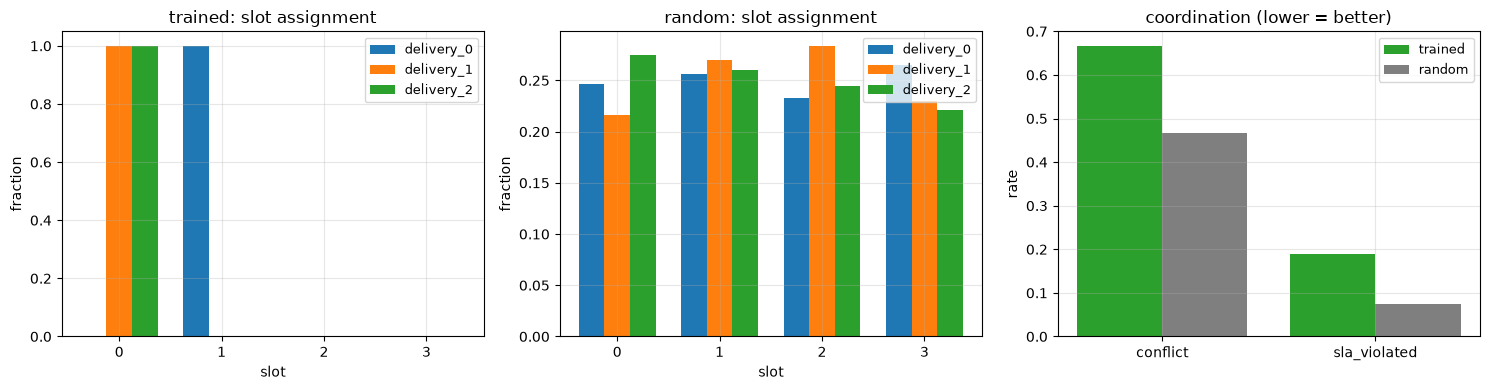

trained: conflict=0.667 sla=0.188  |  random: conflict=0.467 sla=0.075


In [4]:
def delivery_stats(agents, env, n_episodes=30):
    slots = {a: [] for a in delivery}
    conflict, sla = [], []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            actions = {a: agents[a].act(obs[a], explore=False) for a in agents}
            for a in delivery:
                slots[a].append(int(actions[a]))
            obs, _, term, trunc, infos = env.step(actions)
            conflict.append(np.mean([infos[a]["conflict"] for a in delivery]))
            sla.append(np.mean([infos[a]["sla_violated"] for a in delivery]))
            done = term["__all__"] or trunc["__all__"]
    return slots, float(np.mean(conflict)), float(np.mean(sla))


env = ColdChainTrainingEnv(env_config(COMPARE_SEED, delivery))
trained = build_agents(env, delivery)
trained[delivery[0]].load(module_dir(delivery[0]))
t_slots, t_conf, t_sla = delivery_stats(trained, env)

env = ColdChainTrainingEnv(env_config(COMPARE_SEED, delivery))
rand = build_agents(env, delivery)
for a in delivery:
    rand[a] = RandomAgent(env.action_space(a))
r_slots, r_conf, r_sla = delivery_stats(rand, env)

x = np.arange(N_DELIVERY_WINDOWS)
width = 0.25
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, slots, tag in ((axes[0], t_slots, "trained"), (axes[1], r_slots, "random")):
    for k, a in enumerate(delivery):
        counts = np.bincount(slots[a], minlength=N_DELIVERY_WINDOWS)
        ax.bar(x + (k - 1) * width, counts / counts.sum(), width, label=a)
    ax.set(title=f"{tag}: slot assignment", xlabel="slot", ylabel="fraction", xticks=x)
    ax.legend(fontsize=9)

pairs = [("conflict", t_conf, r_conf), ("sla_violated", t_sla, r_sla)]
xp = np.arange(len(pairs))
axes[2].bar(xp - 0.2, [p[1] for p in pairs], 0.4, label="trained", color="tab:green")
axes[2].bar(xp + 0.2, [p[2] for p in pairs], 0.4, label="random", color="tab:gray")
axes[2].set(title="coordination (lower = better)", xticks=xp,
            xticklabels=[p[0] for p in pairs], ylabel="rate")
axes[2].legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f"trained: conflict={t_conf:.3f} sla={t_sla:.3f}  |  "
      f"random: conflict={r_conf:.3f} sla={r_sla:.3f}")